In [1]:
#importing necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans,AgglomerativeClustering,DBSCAN
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

from sklearn.datasets import make_circles


import warnings
warnings.filterwarnings('ignore')

21] Generate synthetic data with 4 centers using make_blobs and apply K-Means clustering. Visualize using a 
scatter plot

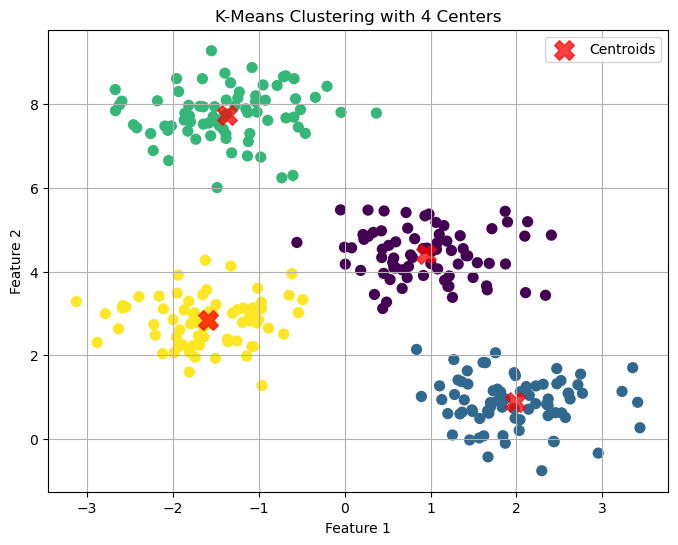

In [5]:
# Step 1: Generate synthetic data
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# Step 2: Apply KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=0)
y_kmeans = kmeans.fit_predict(X)

# Step 3: Visualize using a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='red', s=200, alpha=0.75, marker='X', label='Centroids')
plt.title("K-Means Clustering with 4 Centers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

22] Load the Iris dataset and use Agglomerative Clustering to group the data into 3 clusters. Display the first 10 
predicted labels

In [7]:
# Step 1: Load the Iris dataset
iris = load_iris()
X = iris.data  # Using all four features

# Step 2: Apply Agglomerative Clustering with 3 clusters
agg_clustering = AgglomerativeClustering(n_clusters=3)
labels = agg_clustering.fit_predict(X)

# Step 3: Display the first 10 predicted labels
print("First 10 predicted cluster labels:")
print(labels[:10])

First 10 predicted cluster labels:
[1 1 1 1 1 1 1 1 1 1]


23]Generate synthetic data using make_moons and apply DBSCAN. Highlight outliers in the plot

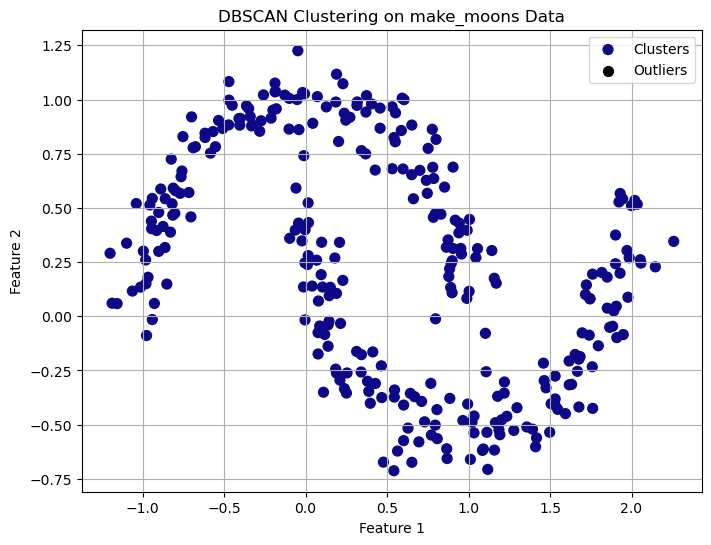

In [10]:
from sklearn.datasets import make_moons

# Step 1: Generate synthetic moon-shaped data
X, _ = make_moons(n_samples=300, noise=0.1, random_state=0)

# Step 2: Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

# Step 3: Plot the clusters and highlight outliers
plt.figure(figsize=(8, 6))

# Core and border points
plt.scatter(X[labels != -1, 0], X[labels != -1, 1], 
            c=labels[labels != -1], cmap='plasma', s=50, label='Clusters')

# Noise (outliers)
plt.scatter(X[labels == -1, 0], X[labels == -1, 1], 
            c='black', s=50, label='Outliers')

plt.title("DBSCAN Clustering on make_moons Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

24] Load the Wine dataset and apply K-Means clustering after standardizing the features. Print the size of each 
cluster

In [15]:
from sklearn.datasets import load_wine


from sklearn.cluster import KMeans

# Step 1: Load the Wine dataset
wine = load_wine()
X = wine.data

# Step 2: Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply K-Means clustering (let’s use 3 clusters to match the wine classes)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

# Step 4: Print the size of each cluster
unique, counts = np.unique(kmeans.labels_, return_counts=True)
for cluster_id, size in zip(unique, counts):
    print(f"Cluster {cluster_id}: {size} samples")

Cluster 0: 65 samples
Cluster 1: 51 samples
Cluster 2: 62 samples


25]Use make_circles to generate synthetic data and cluster it using DBSCAN. Plot the result

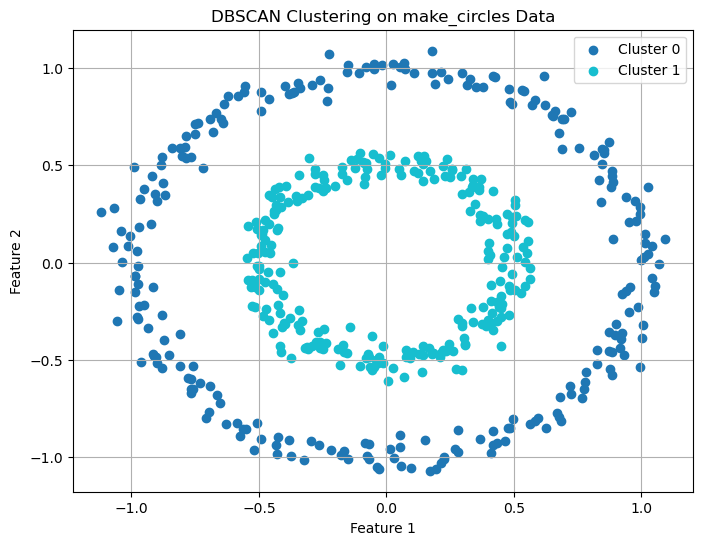

In [2]:
# Step 1: Generate synthetic data
X, y = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=0)

# Step 2: Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

# Step 3: Plot the results
plt.figure(figsize=(8, 6))

# Unique cluster labels (including noise, labeled as -1)
unique_labels = set(labels)

# Assign colors to clusters
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    mask = (labels == label)
    if label == -1:
        # Noise
        plt.scatter(X[mask, 0], X[mask, 1], c='k', marker='x', label='Noise')
    else:
        plt.scatter(X[mask, 0], X[mask, 1], c=[color], label=f'Cluster {label}')

plt.title('DBSCAN Clustering on make_circles Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

26] Load the Breast Cancer dataset, apply MinMaxScaler, and use K-Means with 2 clusters. Output the cluster 
centroids

In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

from sklearn.datasets import load_breast_cancer

# Step 1: Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
feature_names = data.feature_names

# Step 2: Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply KMeans with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(X_scaled)

# Step 4: Output the cluster centroids
centroids = kmeans.cluster_centers_
centroids_df = pd.DataFrame(centroids, columns=feature_names)

# Show the result
print("Cluster Centroids:\n")
print(centroids_df.round(3))


Cluster Centroids:

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        0.255         0.288           0.247      0.144            0.357   
1        0.505         0.396           0.506      0.364            0.470   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0             0.180           0.103                0.131          0.340   
1             0.422           0.418                0.469          0.459   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0                   0.256  ...         0.205          0.321            0.192   
1                   0.299  ...         0.480          0.451            0.466   

   worst area  worst smoothness  worst compactness  worst concavity  \
0       0.099             0.357              0.149            0.131   
1       0.315             0.499              0.364            0.390   

   worst concave points  worst symmetry  worst fractal dimension  
0  

27] Generate synthetic data using make_blobs with varying cluster standard deviations and cluster with 
DBSCAN

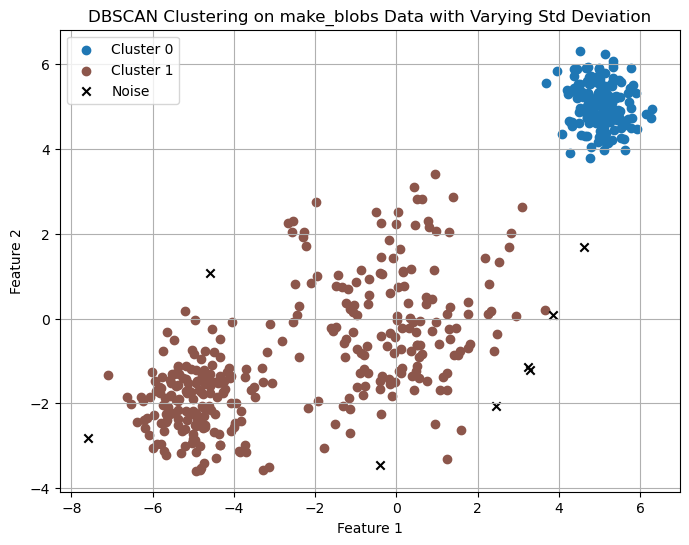

In [4]:
# Step 1: Generate synthetic data with varying standard deviations
X, y = make_blobs(n_samples=500,
                  centers=[[-5, -2], [0, 0], [5, 5]],
                  cluster_std=[0.8, 1.5, 0.5],
                  random_state=42)

# Step 2: Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.9, min_samples=5)
labels = dbscan.fit_predict(X)

# Step 3: Plot the result
plt.figure(figsize=(8, 6))
unique_labels = set(labels)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    mask = (labels == label)
    if label == -1:
        plt.scatter(X[mask, 0], X[mask, 1], c='k', marker='x', label='Noise')
    else:
        plt.scatter(X[mask, 0], X[mask, 1], c=[color], label=f'Cluster {label}')

plt.title("DBSCAN Clustering on make_blobs Data with Varying Std Deviation")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()


28] Load the Digits dataset, reduce it to 2D using PCA, and visualize clusters from K-Means

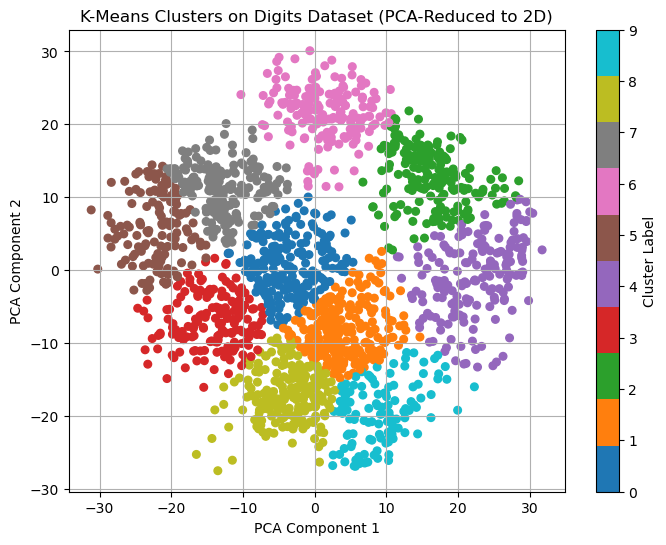

In [5]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

# Step 1: Load the Digits dataset
digits = load_digits()
X = digits.data
y = digits.target  # (optional: true labels)

# Step 2: Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Step 3: Apply K-Means clustering
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(X_pca)

# Step 4: Plot the clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='tab10', s=30)
plt.title("K-Means Clusters on Digits Dataset (PCA-Reduced to 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label='Cluster Label')
plt.grid(True)
plt.show()

29] Create synthetic data using make_blobs and evaluate silhouette scores for k = 2 to 5. Display as a bar chart

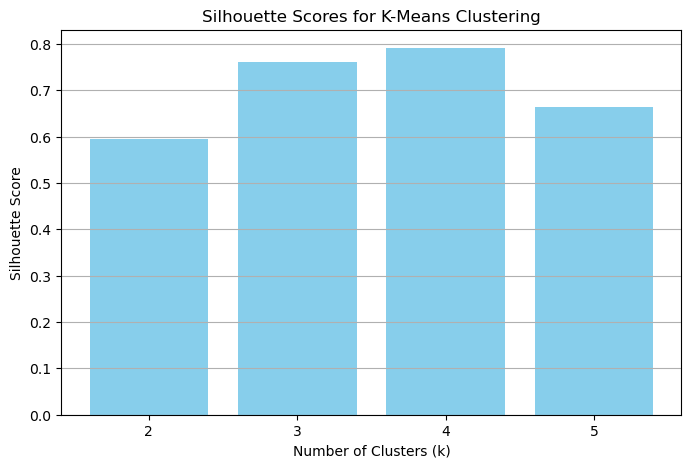

In [6]:
from sklearn.metrics import silhouette_score

# Step 1: Generate synthetic data
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=1.0, random_state=42)

# Step 2: Evaluate silhouette scores for k = 2 to 5
k_values = range(2, 6)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

# Step 3: Plot silhouette scores as a bar chart
plt.figure(figsize=(8, 5))
plt.bar(k_values, silhouette_scores, color='skyblue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for K-Means Clustering')
plt.xticks(k_values)
plt.grid(axis='y')
plt.show()


30] Load the Iris dataset and use hierarchical clustering to group data. Plot a dendrogram with average linkage

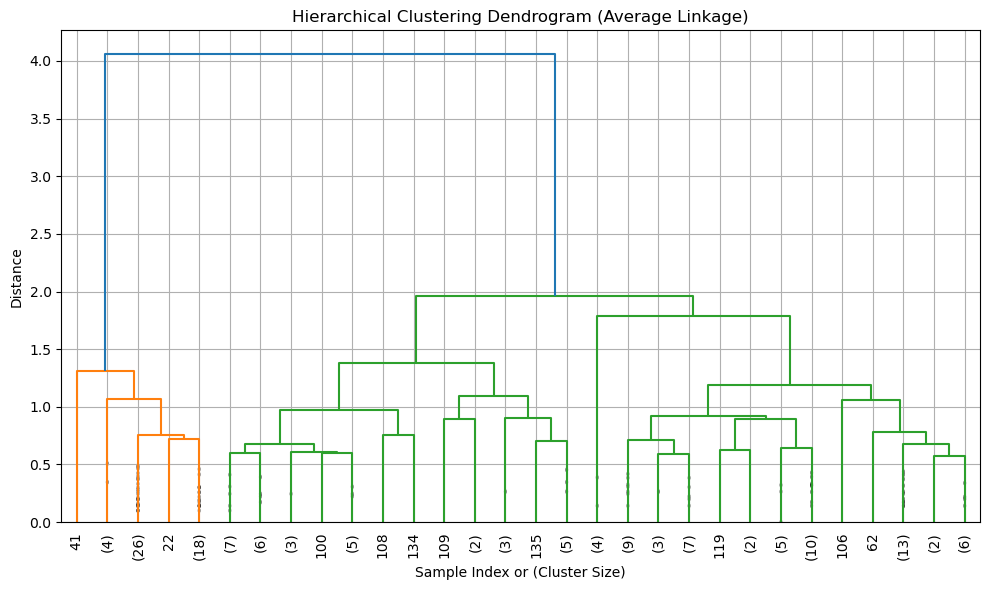

In [7]:
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import dendrogram, linkage

# Step 1: Load the Iris dataset
iris = load_iris()
X = iris.data
feature_names = iris.feature_names

# Step 2: Compute linkage matrix using average linkage
Z = linkage(X, method='average')

# Step 3: Plot the dendrogram
plt.figure(figsize=(10, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.title("Hierarchical Clustering Dendrogram (Average Linkage)")
plt.xlabel("Sample Index or (Cluster Size)")
plt.ylabel("Distance")
plt.grid(True)
plt.tight_layout()
plt.show()


31] Generate synthetic data with overlapping clusters using make_blobs, then apply K-Means and visualize with 
decision boundaries

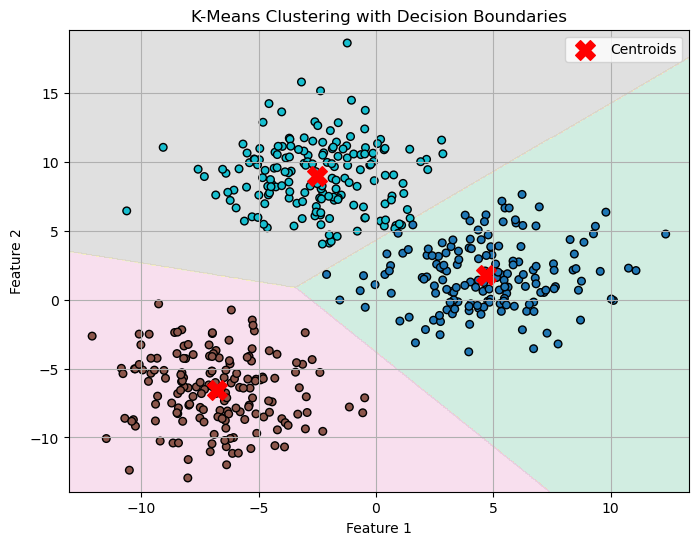

In [8]:
# Step 1: Generate overlapping clusters
X, y = make_blobs(n_samples=500, centers=3, cluster_std=2.5, random_state=42)

# Step 2: Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Step 3: Plot decision boundaries
# Create mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Predict labels for each point in mesh
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Step 4: Plot everything
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap='Pastel2', alpha=0.6)
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=30, edgecolor='k')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title("K-Means Clustering with Decision Boundaries")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()


32] Load the Digits dataset and apply DBSCAN after reducing dimensions with t-SNE. Visualize the results

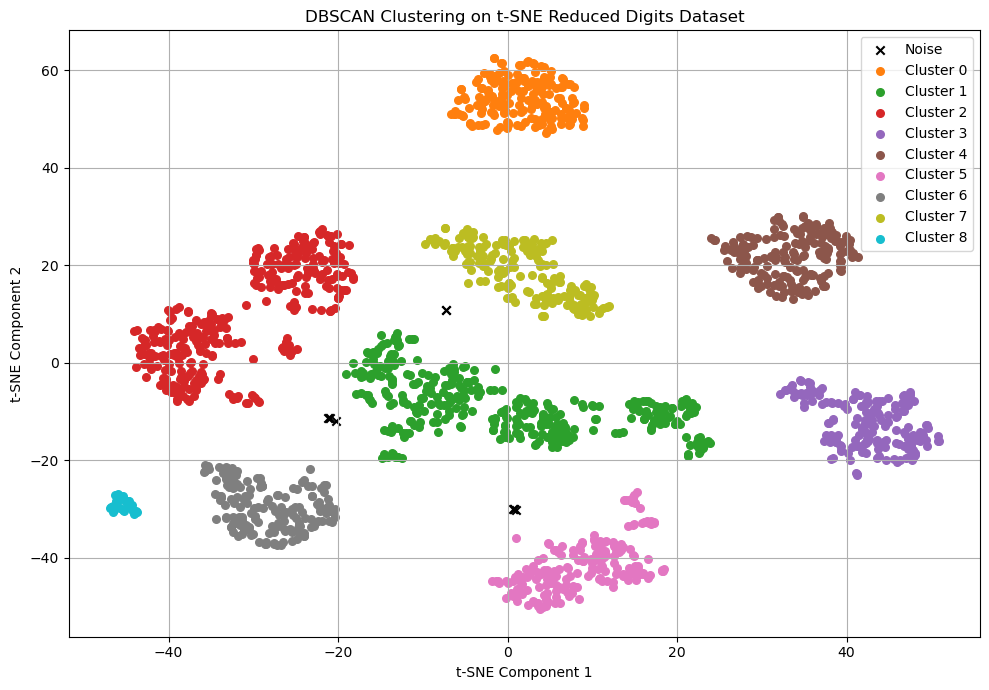

In [10]:
from sklearn.manifold import TSNE
# Step 1: Load the Digits dataset
digits = load_digits()
X = digits.data
y = digits.target  # optional: true labels

# Step 2: Reduce dimensions to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
X_tsne = tsne.fit_transform(X)

# Step 3: Apply DBSCAN clustering
dbscan = DBSCAN(eps=5, min_samples=5)
labels = dbscan.fit_predict(X_tsne)

# Step 4: Visualize results
plt.figure(figsize=(10, 7))
unique_labels = np.unique(labels)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    mask = labels == label
    if label == -1:
        plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c='k', marker='x', label='Noise')
    else:
        plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=[color], label=f'Cluster {label}', s=30)

plt.title("DBSCAN Clustering on t-SNE Reduced Digits Dataset")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


33] Generate synthetic data using make_blobs and apply Agglomerative Clustering with complete linkage. Plot 
the result

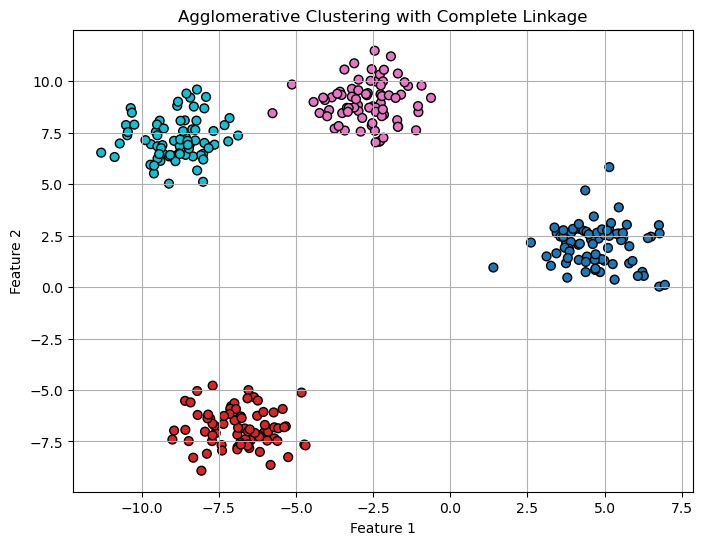

In [11]:
from sklearn.cluster import AgglomerativeClustering

# Step 1: Generate synthetic data
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=42)

# Step 2: Apply Agglomerative Clustering with 'complete' linkage
agglo = AgglomerativeClustering(n_clusters=4, linkage='complete')
labels = agglo.fit_predict(X)

# Step 3: Plot the result
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=40, edgecolor='k')
plt.title("Agglomerative Clustering with Complete Linkage")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

34] Load the Breast Cancer dataset and compare inertia values for K = 2 to 6 using K-Means. Show results in a 
line plot

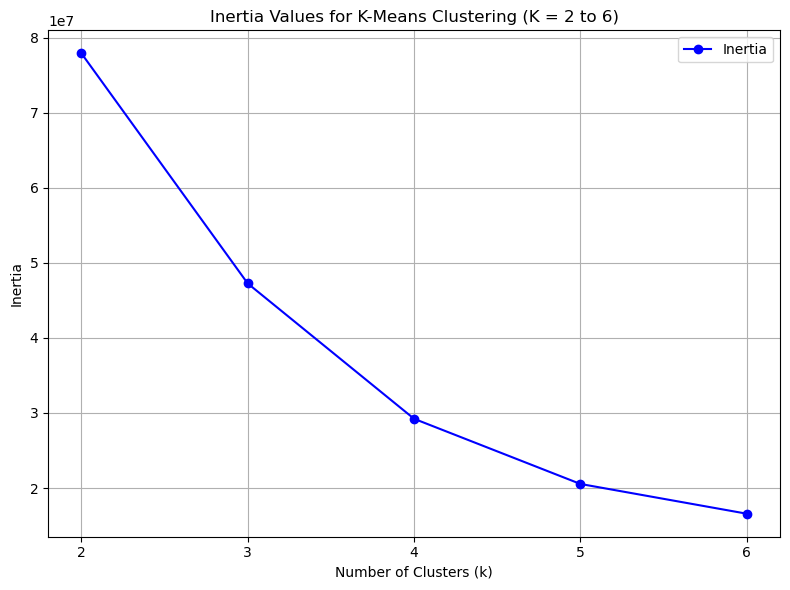

In [12]:
# Step 1: Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data

# Step 2: Compute inertia values for k = 2 to 6
k_values = range(2, 7)
inertia_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)

# Step 3: Plot the inertia values
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia_values, marker='o', linestyle='-', color='b', label='Inertia')
plt.title('Inertia Values for K-Means Clustering (K = 2 to 6)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


35] Generate synthetic concentric circles using make_circles and cluster using Agglomerative Clustering with 
single linkage

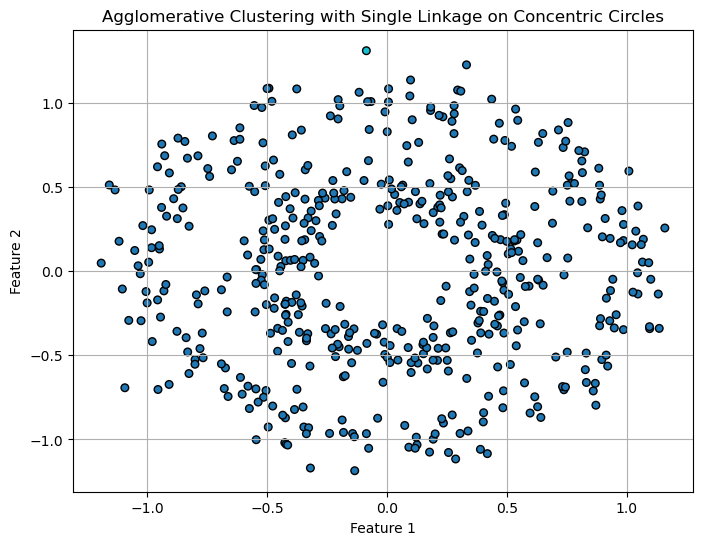

In [13]:
# Step 1: Generate synthetic concentric circles data
X, y = make_circles(n_samples=500, factor=0.5, noise=0.1, random_state=42)

# Step 2: Apply Agglomerative Clustering with 'single' linkage
agglo = AgglomerativeClustering(n_clusters=2, linkage='single')
labels = agglo.fit_predict(X)

# Step 3: Plot the result
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=30, edgecolor='k')
plt.title("Agglomerative Clustering with Single Linkage on Concentric Circles")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()


36] Use the Wine dataset, apply DBSCAN after scaling the data, and count the number of clusters (excluding 
noise)

In [15]:
from sklearn.datasets import load_wine

# Step 1: Load the Wine dataset
wine = load_wine()
X = wine.data

# Step 2: Scale the data using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# Step 4: Count the number of clusters (excluding noise)
# Noise points are labeled as -1
clusters = len(set(labels)) - (1 if -1 in labels else 0)

print(f"Number of clusters (excluding noise): {clusters}")

Number of clusters (excluding noise): 0


37] Generate synthetic data with make_blobs and apply KMeans. Then plot the cluster centers on top of the 
data points

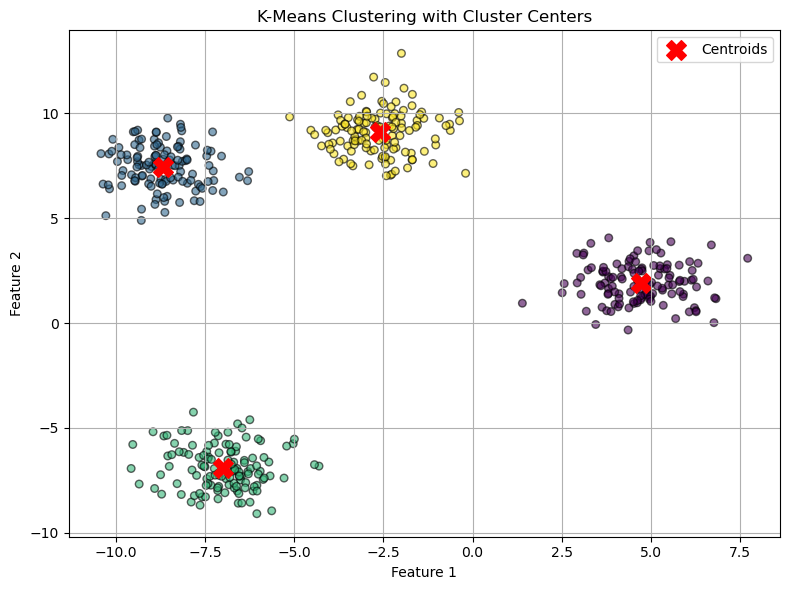

In [16]:
# Step 1: Generate synthetic data
X, y = make_blobs(n_samples=500, centers=4, random_state=42)

# Step 2: Apply KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Step 3: Plot the data points and cluster centers
plt.figure(figsize=(8, 6))

# Plot the data points with cluster labels
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30, edgecolor='k', alpha=0.6)

# Plot the cluster centers
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')

# Title and labels
plt.title("K-Means Clustering with Cluster Centers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

38] Load the Iris dataset, cluster with DBSCAN, and print how many samples were identified as noise

In [17]:
# Step 1: Load the Iris dataset
iris = load_iris()
X = iris.data

# Step 2: Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X)

# Step 3: Count the number of samples identified as noise
# Noise points are labeled as -1
noise_samples = (labels == -1).sum()

print(f"Number of samples identified as noise: {noise_samples}")


Number of samples identified as noise: 17


39] Generate synthetic non-linearly separable data using make_moons, apply K-Means, and visualize the 
clustering result

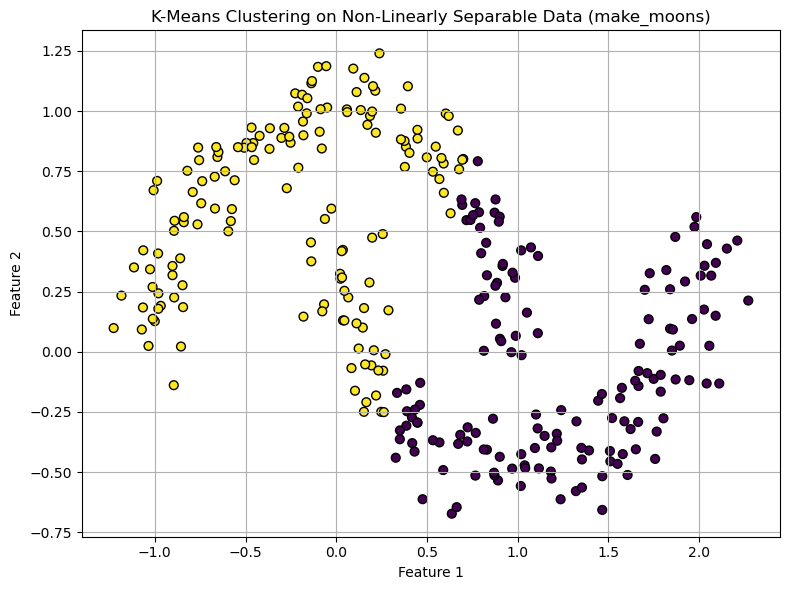

In [19]:
from sklearn.datasets import make_moons


# Step 1: Generate synthetic non-linear data
X, y = make_moons(n_samples=300, noise=0.1, random_state=42)

# Step 2: Apply KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X)

# Step 3: Plot the clustering result
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolor='k', s=40)
plt.title("K-Means Clustering on Non-Linearly Separable Data (make_moons)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.tight_layout()
plt.show()

40] Load the Digits dataset, apply PCA to reduce to 3 components, then use KMeans and visualize with a 3D 
scatter plot

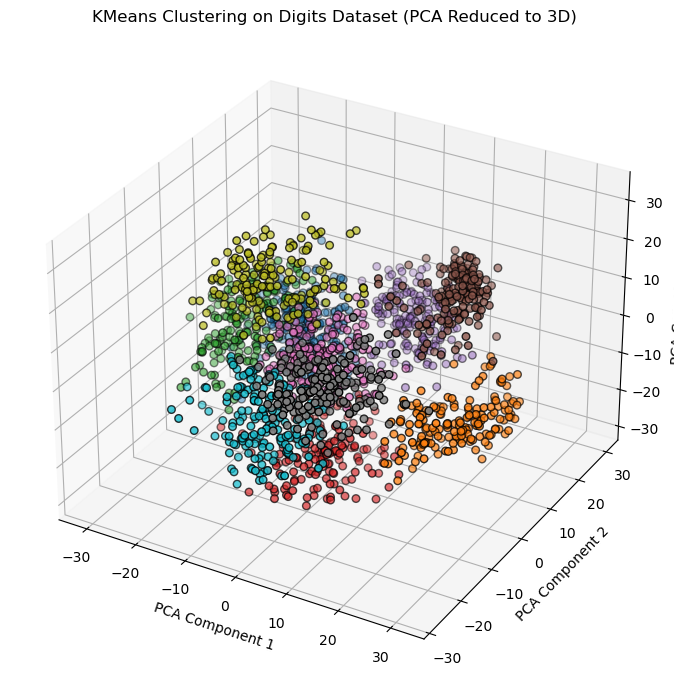

In [20]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

# Step 1: Load the Digits dataset
digits = load_digits()
X = digits.data

# Step 2: Apply PCA to reduce to 3 components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

# Step 3: Apply KMeans clustering
kmeans = KMeans(n_clusters=10, random_state=42)
labels = kmeans.fit_predict(X_pca)

# Step 4: 3D Scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                     c=labels, cmap='tab10', s=30, edgecolor='k')

ax.set_title("KMeans Clustering on Digits Dataset (PCA Reduced to 3D)")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
plt.tight_layout()
plt.show()


41]Generate synthetic blobs with 5 centers and apply KMeans. Then use silhouette_score to evaluate the 
clustering

In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# Step 1: Generate synthetic data
X, y_true = make_blobs(n_samples=500, centers=5, cluster_std=1.0, random_state=42)

# Step 2: Apply KMeans with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X)

# Step 3: Calculate Silhouette Score
score = silhouette_score(X, labels)

# Step 4: Output result
print(f"Silhouette Score for KMeans with 5 clusters: {score:.3f}")


Silhouette Score for KMeans with 5 clusters: 0.679


42] Load the Breast Cancer dataset, reduce dimensionality using PCA, and apply Agglomerative Clustering. 
Visualize in 2D

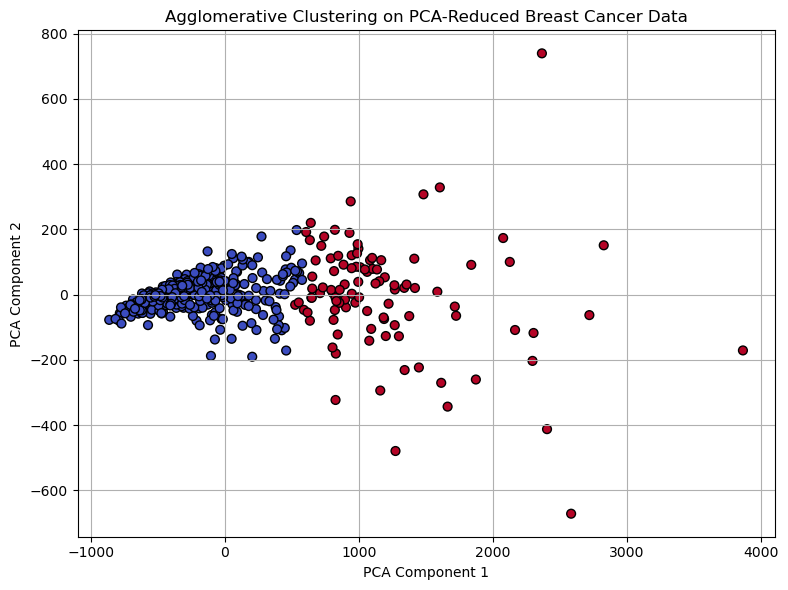

In [22]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

# Step 1: Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data

# Step 2: Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Step 3: Apply Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels = agglo.fit_predict(X_pca)

# Step 4: Visualize the clustering in 2D
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='coolwarm', edgecolor='k', s=40)
plt.title("Agglomerative Clustering on PCA-Reduced Breast Cancer Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()


43] Generate noisy circular data using make_circles and visualize clustering results from KMeans and DBSCAN 
side-by-side

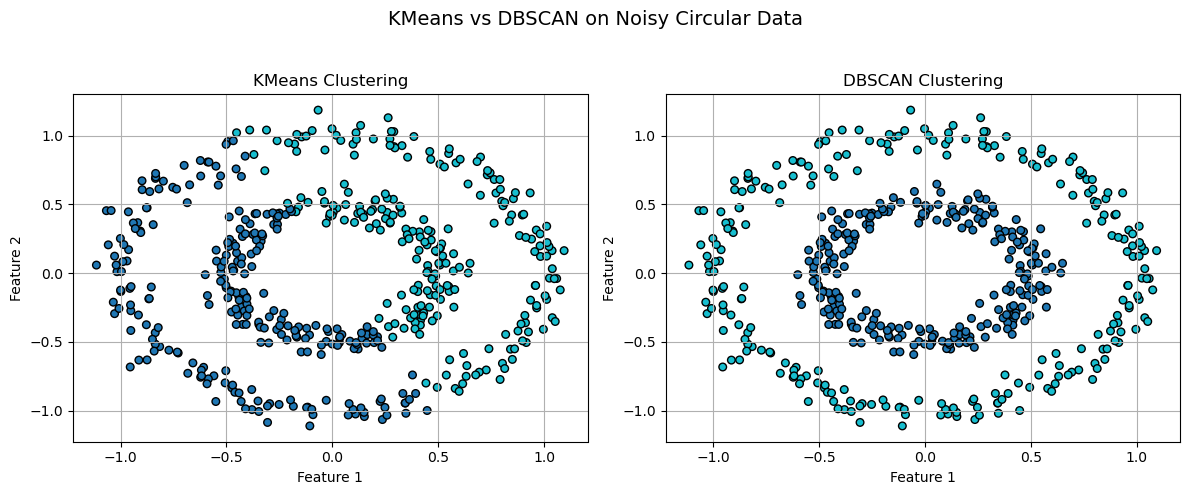

In [23]:
# Step 1: Generate noisy circular data
X, y_true = make_circles(n_samples=500, factor=0.5, noise=0.06, random_state=42)

# Step 2: Apply KMeans (will struggle with non-linear shapes)
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

# Step 3: Apply DBSCAN (designed for arbitrary shapes)
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

# Step 4: Visualize side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# KMeans plot
axes[0].scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='tab10', edgecolor='k', s=30)
axes[0].set_title("KMeans Clustering")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].grid(True)

# DBSCAN plot
axes[1].scatter(X[:, 0], X[:, 1], c=dbscan_labels, cmap='tab10', edgecolor='k', s=30)
axes[1].set_title("DBSCAN Clustering")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].grid(True)

plt.suptitle("KMeans vs DBSCAN on Noisy Circular Data", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

44] Load the Iris dataset and plot the Silhouette Coefficient for each sample after KMeans clustering

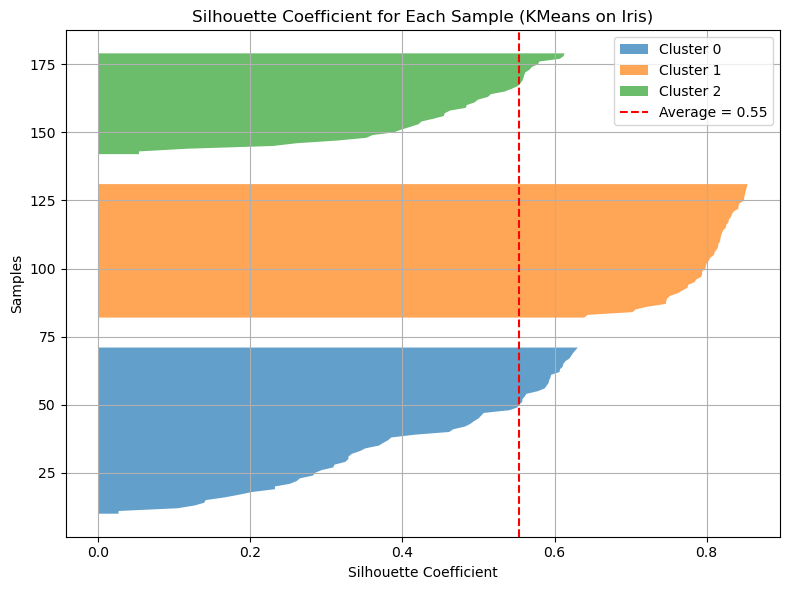

In [26]:
from sklearn.metrics import silhouette_samples, silhouette_score


# Step 1: Load the Iris dataset
iris = load_iris()
X = iris.data

# Step 2: Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

# Step 3: Compute silhouette scores for each sample
silhouette_vals = silhouette_samples(X, labels)
avg_silhouette = silhouette_score(X, labels)

# Step 4: Plot the silhouette scores
plt.figure(figsize=(8, 6))
y_lower = 10
for i in np.unique(labels):
    ith_cluster_silhouette_vals = silhouette_vals[labels == i]
    ith_cluster_silhouette_vals.sort()
    size_cluster_i = ith_cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i

    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_vals,
                      alpha=0.7, label=f'Cluster {i}')
    y_lower = y_upper + 10

plt.axvline(avg_silhouette, color="red", linestyle="--", label=f"Average = {avg_silhouette:.2f}")
plt.title("Silhouette Coefficient for Each Sample (KMeans on Iris)")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Samples")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

45] Generate synthetic data using make_blobs and apply Agglomerative Clustering with 'average' linkage. 
Visualize clusters

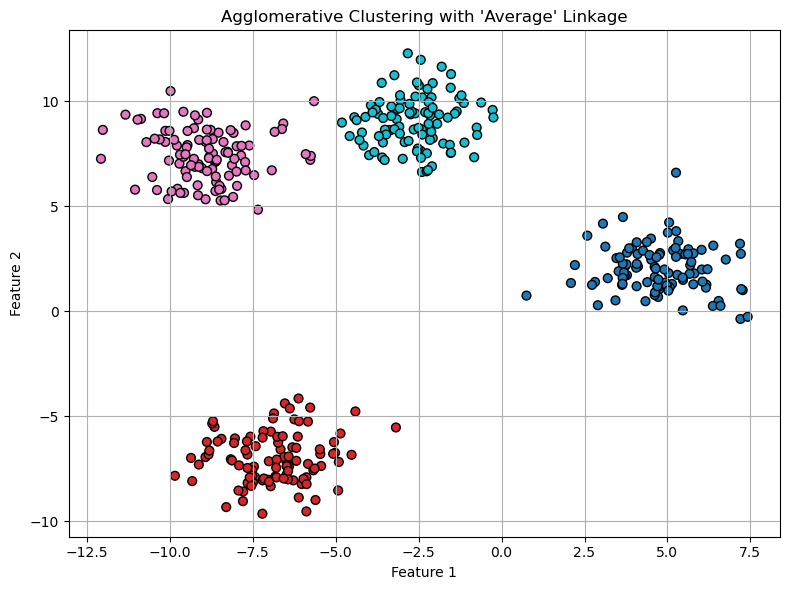

In [27]:
# Step 1: Generate synthetic data
X, y_true = make_blobs(n_samples=400, centers=4, cluster_std=1.2, random_state=42)

# Step 2: Apply Agglomerative Clustering with 'average' linkage
agglo = AgglomerativeClustering(n_clusters=4, linkage='average')
labels = agglo.fit_predict(X)

# Step 3: Visualize the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=40, edgecolor='k')
plt.title("Agglomerative Clustering with 'Average' Linkage")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.tight_layout()
plt.show()

46] Load the Wine dataset, apply KMeans, and visualize the cluster assignments in a seaborn pairplot (first 4 
features)

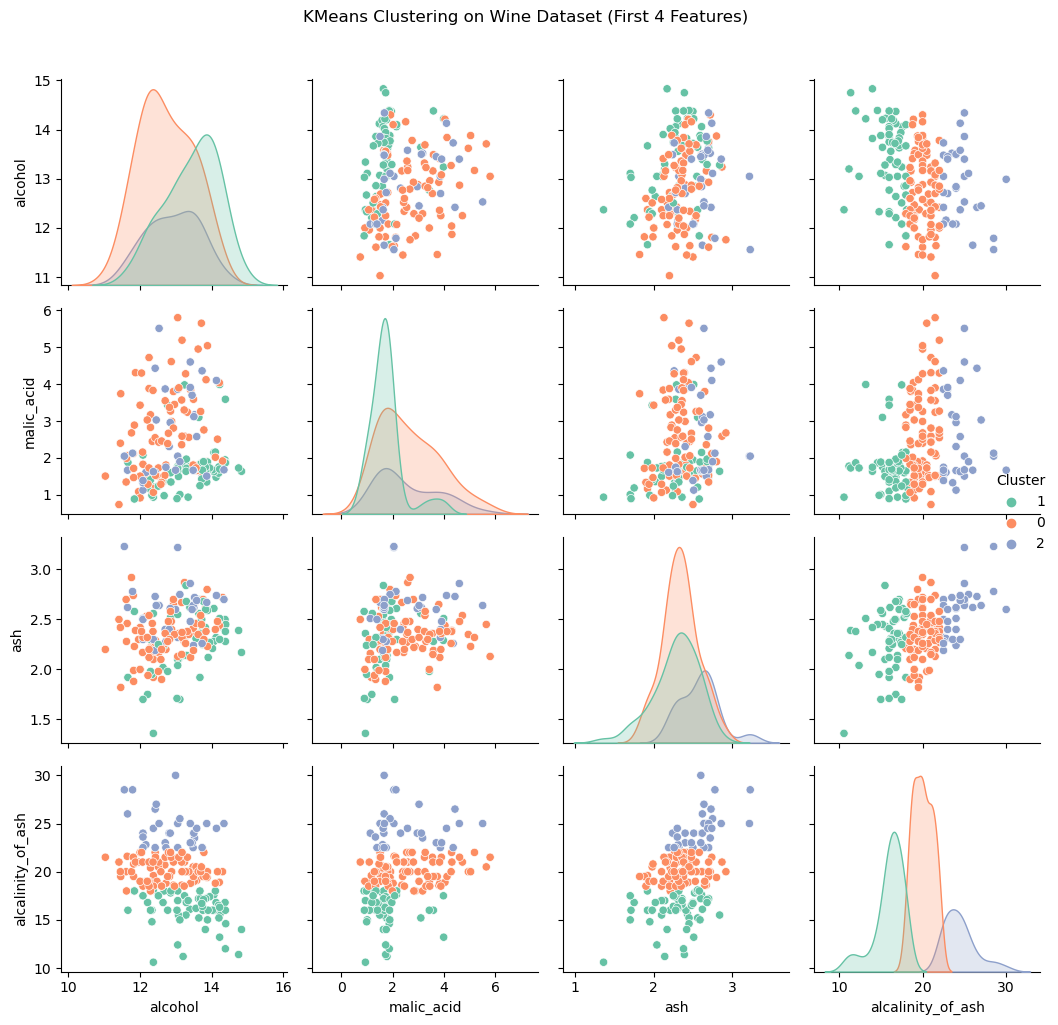

In [29]:
import seaborn as sns
# Step 1: Load the Wine dataset
wine = load_wine()
X = wine.data[:, :4]  # Use only the first 4 features
feature_names = wine.feature_names[:4]

# Step 2: Convert to a DataFrame
df = pd.DataFrame(X, columns=feature_names)

# Step 3: Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X).astype(str)  # Convert to string for better legend

# Step 4: Visualize using seaborn pairplot
sns.pairplot(df, hue='Cluster', palette='Set2', diag_kind='kde')
plt.suptitle("KMeans Clustering on Wine Dataset (First 4 Features)", y=1.02)
plt.tight_layout()
plt.show()

47] Generate noisy blobs using make_blobs and use DBSCAN to identify both clusters and noise points. Print the 
count

In [30]:
# Step 1: Generate noisy blob data
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=1.0, random_state=42)

# Step 2: Apply DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X)

# Step 3: Count clusters and noise
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

# Step 4: Print the results
print(f"Number of clusters found (excluding noise): {n_clusters}")
print(f"Number of noise points: {n_noise}")

Number of clusters found (excluding noise): 6
Number of noise points: 67


48] Load the Digits dataset, reduce dimensions using t-SNE, then apply Agglomerative Clustering and plot the 
clusters.

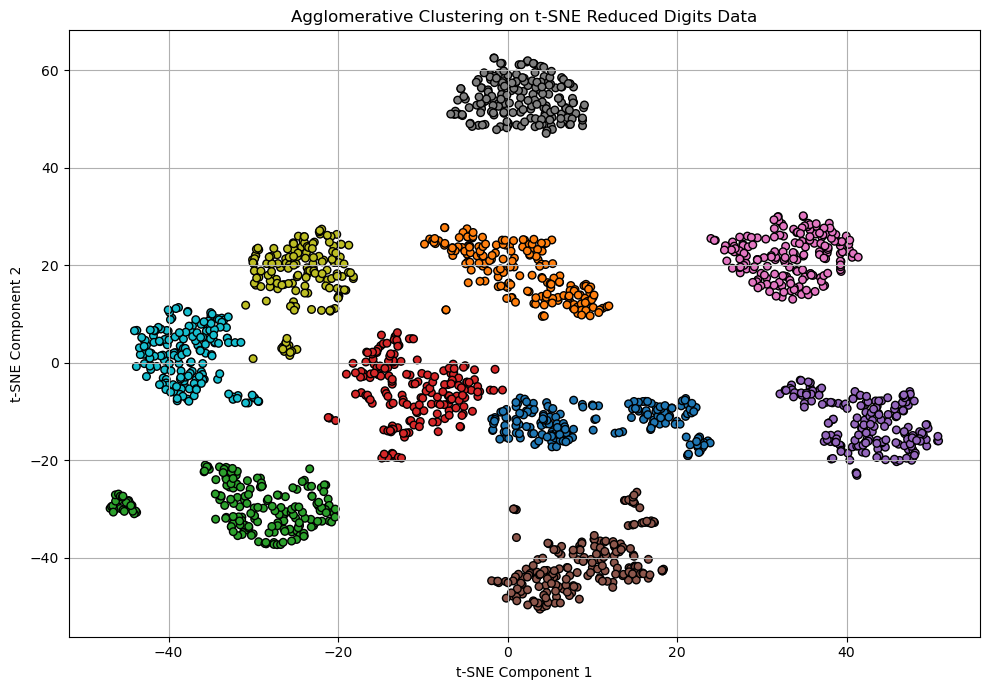

In [31]:
# Step 1: Load the Digits dataset
digits = load_digits()
X = digits.data

# Step 2: Reduce dimensions using t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X)

# Step 3: Apply Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=10, linkage='ward')
labels = agglo.fit_predict(X_tsne)

# Step 4: Plot the clusters
plt.figure(figsize=(10, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=30, edgecolor='k')
plt.title("Agglomerative Clustering on t-SNE Reduced Digits Data")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()